# Auto MPG


Target variable: Miles per Gallon (mpg)

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Load Data

In [28]:
# Define column names for dataset, taken from UCI ML Respository
columns = [
    "mpg",
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year",
    "origin",
    "car_name"
]

# Load data
df = pd.read_csv(
    "../data/auto-mpg.data",
    sep=r"\s+",
    names=columns,
    na_values="?",
    quotechar='"'
)

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [29]:
# Look at shape and info of dataset
print("Shape:", df.shape)
df.info()

Shape: (398, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 28.1+ KB


The original Auto MPG dataset has 398 examples and 9 features.

# Preprocessing

In [30]:
# Check string values
df.dtypes

# Remove string attributes from dataset
df = df.drop(columns = ["car_name"])

# Remove origin column since it's categorical
df = df.drop(columns = ["origin"])

In [31]:
# Check for missing values
df.isna().sum()
print("Percentage missing: ", df["horsepower"].isna().sum() / len(df) * 100)

# Remove missing values from dataset
df = df.dropna()

Percentage missing:  1.507537688442211


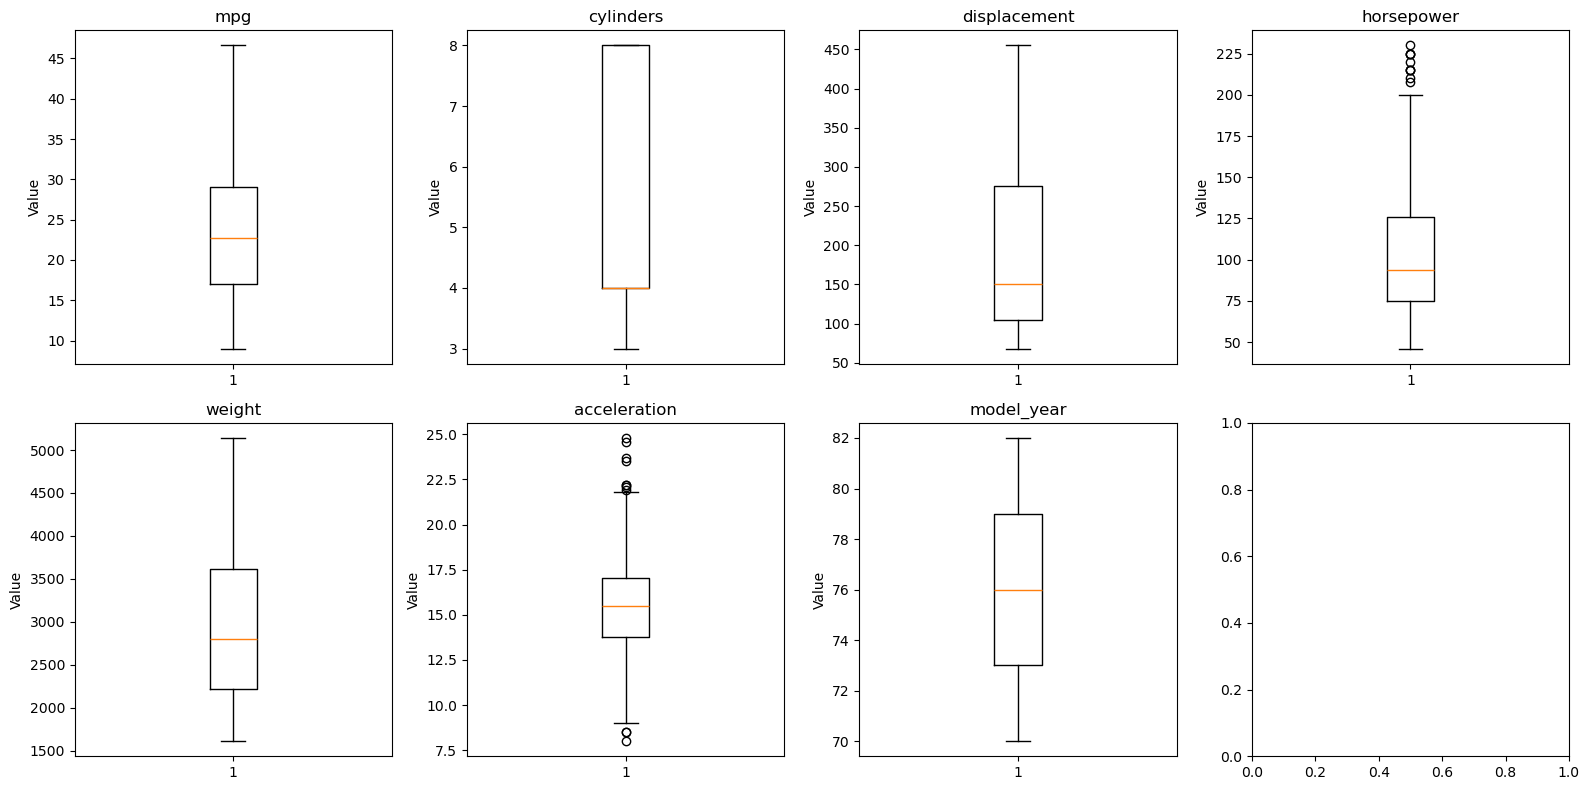

In [32]:
# Check for outliers
df.describe()

# Create boxplots for each column
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, column in zip(axes.flatten(), df.columns):
    ax.boxplot(df[column])
    ax.set_title(column)
    ax.set_ylabel("Value")

plt.tight_layout()
plt.show()

In [33]:
def find_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]
    
    return Q1, Q3, IQR, lower_bound, upper_bound, outliers

for column in df.columns:
    Q1, Q3, IQR, lower, upper, outliers = find_outliers_iqr(df, column)
    
    print(f"\n{column}")
    print(f"Lower bound: {lower:.2f}")
    print(f"Upper bound: {upper:.2f}")
    print(f"Potential outliers: {len(outliers)}")



mpg
Lower bound: -1.00
Upper bound: 47.00
Potential outliers: 0

cylinders
Lower bound: -2.00
Upper bound: 14.00
Potential outliers: 0

displacement
Lower bound: -151.12
Upper bound: 531.88
Potential outliers: 0

horsepower
Lower bound: -1.50
Upper bound: 202.50
Potential outliers: 10

weight
Lower bound: 141.00
Upper bound: 5699.00
Potential outliers: 0

acceleration
Lower bound: 8.90
Upper bound: 21.90
Potential outliers: 11

model_year
Lower bound: 64.00
Upper bound: 88.00
Potential outliers: 0


The `car_name` attribute has String values, as shown as object in the output of df.dtypes. The `origin` attribute is also categorical, with its values encoded as integers 1-3. Since they're categorical variables, we'll exclusde them from the dataset and regression analysis.

There are 6 missing values in the dataset, all in the `horsepower` column. This makes up 1.51% of the dataset, and they were removed from the dataset.

To check for outliers, we created boxplots for each feature. After looking at the boxplots, attributes `horsepower` and `acceleration` both show points above the whiskers, indicating potential outliers. We also used the 1.5 x IRQ rule, which identified 10 potential outliers for `horsepower` and 11 potential outliers for `acceleration`. We decided to keep these points in the data for our analysis because they seem plausible observations like cars with higher horsepower or unusual acceleration values. We don't have any evidence that there were any data-entry errors, so we decided to include these points.

After preprocessing, the final dataset has 392 observations and 7 columns. We'll examine 6 features to see their impact on predictions of `mpg`

In [34]:
# Save as CSV for ScalaTion
df.to_csv("../data/auto_mpg_clean.csv", index=False)

# Features

In [35]:
# Statistical summary of each feature
summary_stats = df.describe().T.round(3)
summary_stats

,count,mean,std,min,25%,50%,75%,max
mpg,392.0,23.446,7.805,9.0,17.000,22.75,29.000,46.6
cylinders,392.0,5.472,1.706,3.0,4.000,4.00,8.000,8.0
displacement,392.0,194.412,104.644,68.0,105.000,151.00,275.750,455.0
horsepower,392.0,104.469,38.491,46.0,75.000,93.50,126.000,230.0
weight,392.0,2977.584,849.403,1613.0,2225.250,2803.50,3614.750,5140.0
acceleration,392.0,15.541,2.759,8.0,13.775,15.50,17.025,24.8
model_year,392.0,75.980,3.684,70.0,73.000,76.00,79.000,82.0


The descriptive statistics show a lot of variation in attributes like `displacement`, `horsepower`, and `weight`, as seen in their ranges. The target variable, `mpg`, also shows substantial variation across observations. Features `weight`, `displacement`, and `horsepower` have means noticeably higher than the median, suggesting possible right skewedness. 

# Correlation Analysis

In [36]:
# Correlation matrix
correlation_matrix = df.corr()
correlation_matrix.round(3)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
mpg,1.000,-0.778,-0.805,-0.778,-0.832,0.423,0.581
cylinders,-0.778,1.000,0.951,0.843,0.898,-0.505,-0.346
displacement,-0.805,0.951,1.000,0.897,0.933,-0.544,-0.370
horsepower,-0.778,0.843,0.897,1.000,0.865,-0.689,-0.416
weight,-0.832,0.898,0.933,0.865,1.000,-0.417,-0.309
acceleration,0.423,-0.505,-0.544,-0.689,-0.417,1.000,0.290
model_year,0.581,-0.346,-0.370,-0.416,-0.309,0.290,1.000


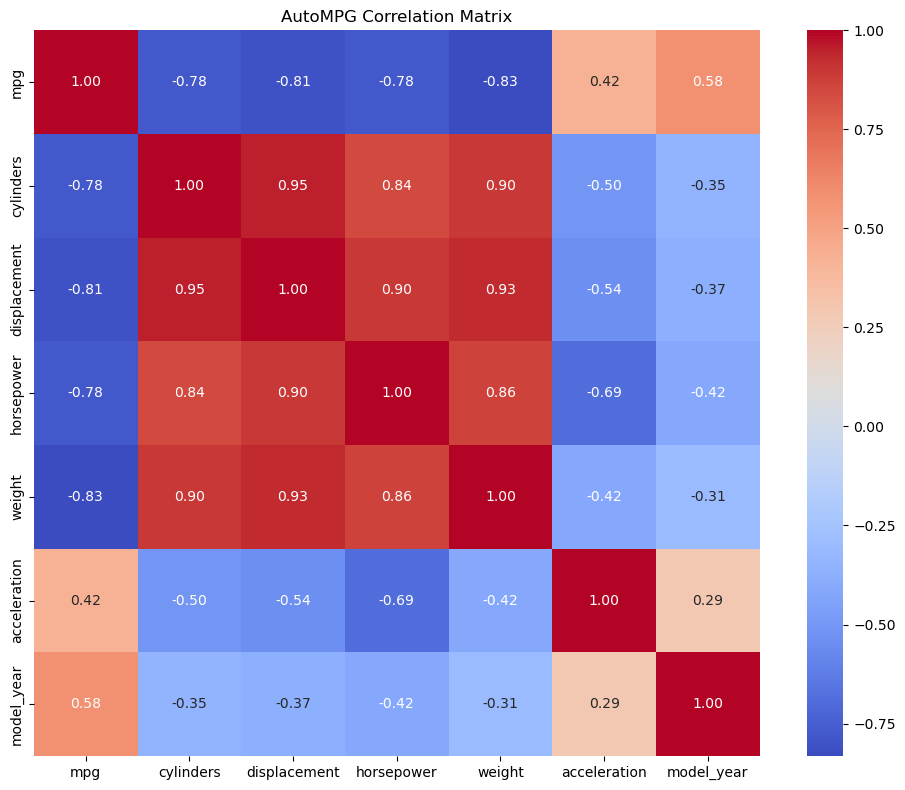

In [37]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot = True,
    fmt = ".2f",
    cmap = "coolwarm",
    square = True
)

plt.title("AutoMPG Correlation Matrix")
plt.tight_layout()

plt.show()

In a correlation matrix, the cells with the highest absolute value (not including 1.0 of the variables' correlation with themselves) reflect the strongest correlation. In the `mpg` column, the cell with `displacement` has a value of -0.805, and `weight` has -0.832. These two cells had the highest absolute values, meaning they had the strongest linear associations with `mpg`. 

This is also shown in the heatmap, where the leftmost column that shows `mpg` has the most intense color in the cells with `displacement` and `weight`

# Fit Models

## Statsmodels

### Displacement

In [46]:
# Select displacement as X
X_displacement = df[["displacement"]] 
y = df["mpg"]

# Add a constant term for the intercept
X_displacement = sm.add_constant(X_displacement)  

model_displacement= sm.OLS(y, X_displacement).fit()
print(model_displacement.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.648
Model:                            OLS   Adj. R-squared:                  0.647
Method:                 Least Squares   F-statistic:                     718.7
Date:                Sun, 06 Sep 2026   Prob (F-statistic):           1.66e-90
Time:                        19:44:02   Log-Likelihood:                -1156.4
No. Observations:                 392   AIC:                             2317.
Df Residuals:                     390   BIC:                             2325.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           35.1206      0.494     71.033   

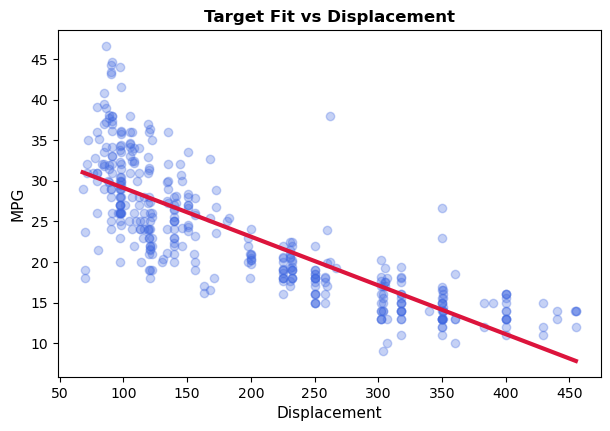

In [47]:
# Create plot of actual values and fitted model
df["y_hat"] = model_displacement.predict(X_displacement)

plt.figure(figsize=(7, 4.5))
plt.scatter(df["displacement"], df["mpg"], color="royalblue", alpha=0.3, label="Actual Values ($y$)")
plt.xlabel("Displacement", fontsize=11)
plt.ylabel("MPG", fontsize=11)
plt.title(f"Target Fit vs Displacement", fontsize=12, weight="bold")


sorted_df = df.sort_values(by="displacement")
plt.plot(sorted_df["displacement"], sorted_df["y_hat"], color="crimson", linewidth=3, label="Fitted Model ($\\hat{y}$)")

Displacement and mpg have a negative correlation, where for every 1 unit increase in displacement, the mpg decreases by approximately 0.0601 units. 

### Weight

In [ ]:
# Select weight as X
X_weight = df[["weight"]] 
y = df["mpg"]

# Add a constant term for the intercept
X_weight = sm.add_constant(X_weight)  

model_weight= sm.OLS(y, X_weight).fit()
print(model_weight.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.693
Model:                            OLS   Adj. R-squared:                  0.692
Method:                 Least Squares   F-statistic:                     878.8
Date:                Sun, 06 Sep 2026   Prob (F-statistic):          6.02e-102
Time:                        19:37:14   Log-Likelihood:                -1130.0
No. Observations:                 392   AIC:                             2264.
Df Residuals:                     390   BIC:                             2272.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         46.2165      0.799     57.867      0.0

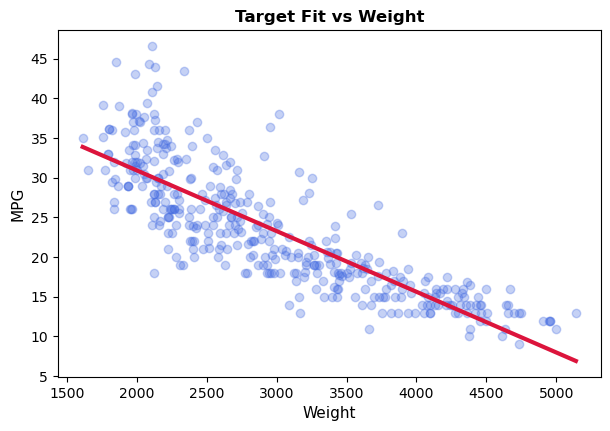

In [43]:
# Create plot of actual values and fitted model
df["y_hat"] = model_weight.predict(X_weight)

plt.figure(figsize=(7, 4.5))
plt.scatter(df["weight"], df["mpg"], color="royalblue", alpha=0.3, label="Actual Values ($y$)")
plt.xlabel("Weight", fontsize=11)
plt.ylabel("MPG", fontsize=11)
plt.title(f"Target Fit vs Weight", fontsize=12, weight="bold")


sorted_df = df.sort_values(by="weight")
plt.plot(sorted_df["weight"], sorted_df["y_hat"], color="crimson", linewidth=3, label="Fitted Model ($\\hat{y}$)")

Weight and mpg have a negative correlation, where for every 1 unit increase in weight, the mpg decreases by approximately 0.0076 units. 